In [ ]:
# Day 4 - Statistical Analysis on Titanic Dataset

## About
Applying descriptive statistics concepts on the real 
Titanic dataset to understand passenger data deeply.

## Topics Covered
- Mean, Median, Mode
- Standard Deviation
- Skewness and Kurtosis
- Correlation with Survival
- Outlier Detection using IQR method
- Normal Distribution Analysis

## Tools Used
- Python, Pandas, Numpy, Seaborn, Matplotlib

In [3]:
# Import all libraries we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Titanic again
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

# Fix missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Cabin'] = df['Cabin'].fillna('Unknown')
df['Embarked'] = df['Embarked'].fillna('Unknown')

print("Dataset ready!")
print("Shape:", df.shape)

Dataset ready!
Shape: (891, 12)


In [4]:
# Basic descriptive statistics
print("=== DESCRIPTIVE STATISTICS ===\n")

# Summary of all numeric columns
print(df.describe())
# Let's focus on meaningful columns
print("=== AGE STATISTICS ===")
print(f"Mean Age: {df['Age'].mean():.2f}")
print(f"Median Age: {df['Age'].median():.2f}")
print(f"Std Deviation: {df['Age'].std():.2f}")
print(f"Skewness: {df['Age'].skew():.2f}")
print(f"Kurtosis: {df['Age'].kurt():.2f}")

print("\n=== FARE STATISTICS ===")
print(f"Mean Fare: {df['Fare'].mean():.2f}")
print(f"Median Fare: {df['Fare'].median():.2f}")
print(f"Std Deviation: {df['Fare'].std():.2f}")
print(f"Skewness: {df['Fare'].skew():.2f}")
print(f"Kurtosis: {df['Fare'].kurt():.2f}")

=== DESCRIPTIVE STATISTICS ===

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  891.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.361582    0.523008   
std     257.353842    0.486592    0.836071   13.019697    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   22.000000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   35.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  
=== AGE STATISTICS ===
Mean Age: 29.36
Median Age

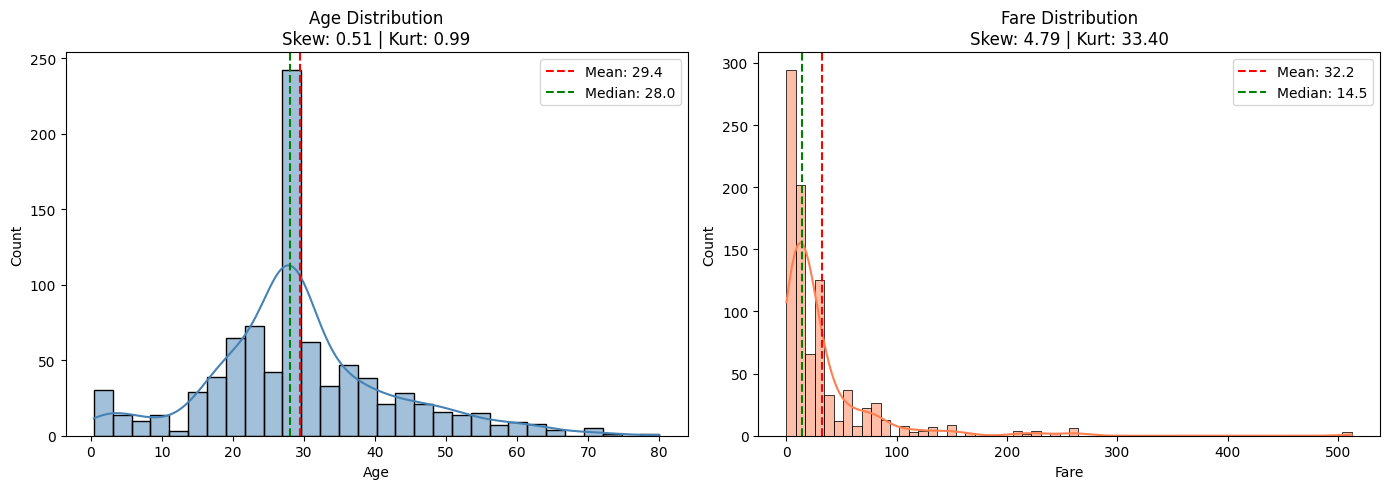

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age Distribution
sns.histplot(df['Age'], kde=True, ax=axes[0], color='steelblue')
axes[0].axvline(df['Age'].mean(), color='red', linestyle='--', label=f'Mean: {df["Age"].mean():.1f}')
axes[0].axvline(df['Age'].median(), color='green', linestyle='--', label=f'Median: {df["Age"].median():.1f}')
axes[0].set_title(f'Age Distribution\nSkew: {df["Age"].skew():.2f} | Kurt: {df["Age"].kurt():.2f}')
axes[0].legend()

# Fare Distribution
sns.histplot(df['Fare'], kde=True, ax=axes[1], color='coral')
axes[1].axvline(df['Fare'].mean(), color='red', linestyle='--', label=f'Mean: {df["Fare"].mean():.1f}')
axes[1].axvline(df['Fare'].median(), color='green', linestyle='--', label=f'Median: {df["Fare"].median():.1f}')
axes[1].set_title(f'Fare Distribution\nSkew: {df["Fare"].skew():.2f} | Kurt: {df["Fare"].kurt():.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

In [6]:
# Apply all stats you studied to Titanic Age column
print("=== AGE STATISTICS ===")
print(f"Mean:{df['Age'].mean():.2f}")
print(f"Median:{df['Age'].median():.2f}")
print("Mode:",df['Age'].mode())
print(f"std:{df['Age'].std():.2f}")
print(f"skewness:{df['Age'].skew():.2f}")
print(f"Kurtosis:{df['Age'].kurt():.2f}")

=== AGE STATISTICS ===
Mean:29.36
Median:28.00
Mode: 0    28.0
Name: Age, dtype: float64
std:13.02
skewness:0.51
Kurtosis:0.99


In [7]:
print(df.info())


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    str    
 11  Embarked     891 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None


In [8]:
print('=====Correlation with Survival=====')
print(df[['Survived','Pclass','Age','SibSp','Parch','Fare']].corr()['Survived'])

=====Correlation with Survival=====
Survived    1.000000
Pclass     -0.338481
Age        -0.064910
SibSp      -0.035322
Parch       0.081629
Fare        0.257307
Name: Survived, dtype: float64


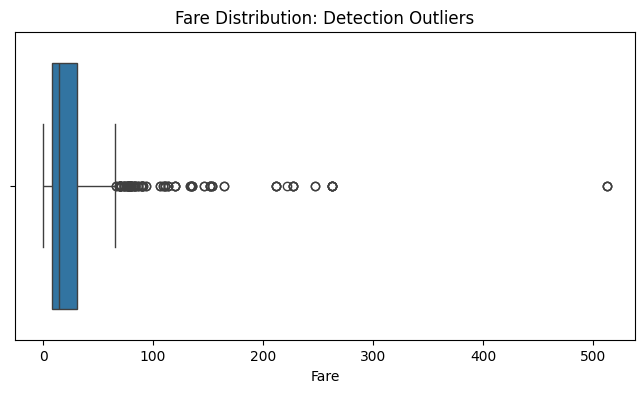

Total Outliers:116
Lower Boundary:-26.72
Upper Boundary:65.63


In [9]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Fare'])
plt.title('Fare Distribution: Detection Outliers')
plt.show()

Q1=df['Fare'].quantile(.25)
Q3=df['Fare'].quantile(.75)
IQR=Q3-Q1

lower=Q1-1.5*IQR
upper=Q3+1.5*IQR

Outliers=df[(df['Fare']<lower)|(df['Fare']>upper)]
print(f'Total Outliers:{len(Outliers)}')
print(f'Lower Boundary:{lower:.2f}')
print(f'Upper Boundary:{upper:.2f}')

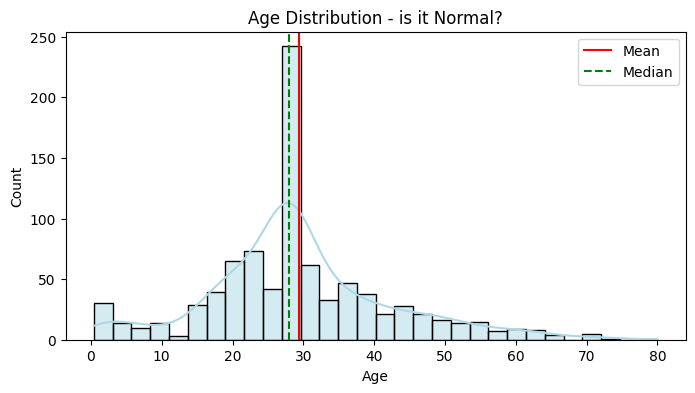

In [19]:
plt.figure(figsize=(8,4))
sns.histplot(df['Age'], kde=True, bins=30, color='lightblue')
plt.title('Age Distribution - is it Normal?')
plt.axvline(df['Age'].mean(), color='red', label='Mean')
plt.axvline(df['Age'].median(), linestyle='--', color='green', label='Median')
plt.legend()
plt.show()

In [ ]:
## Key Statistical Findings

- Average passenger age was 29.36 years
- Age was slightly right skewed (0.51) — few elderly passengers
- Fare had 116 outliers — rich Class 1 passengers paid up to 512
- Fare correlated most with survival (0.26)
- Pclass negatively correlated (-0.34) — lower class = less survival
- Age distribution was almost normal but not perfect
- Artificial spike at age 28 created by filling missing values with median

## Personal Learning
Statistics is not just numbers — it tells the story 
of real people and real events. Every number here 
represents a real Titanic passenger.